<a href="https://colab.research.google.com/github/DhimanTarafdar/AAA/blob/main/vanishing_gradient_problem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Vanishing Gradient Problem (Concept)

Deep Neural Network training করার সময় backpropagation এর মাধ্যমে gradient
প্রতিটি layer দিয়ে propagate হয়।

কিন্তু কিছু activation function (যেমন Sigmoid / Tanh) ব্যবহার করলে
gradient বারবার ছোট হতে হতে প্রায় 0 হয়ে যায়।

এই অবস্থাকে বলা হয় Vanishing Gradient Problem.

যখন gradient খুব ছোট হয়ে যায় তখন:

• weight update প্রায় বন্ধ হয়ে যায়  
• network শেখা বন্ধ করে দেয়  
• early layers train হতে পারে না  

এই notebook-এ আমরা code দিয়ে দেখবো:

1️⃣ Deep network + sigmoid activation  
2️⃣ training এর সময় weight change observe করা  
3️⃣ gradient ছোট হয়ে যাচ্ছে কিনা দেখা

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split


In [3]:

# reproducibility
torch.manual_seed(42)

# Dataset

আমরা sklearn এর make_moons dataset ব্যবহার করছি।

এই dataset:

• non-linear classification problem
• deep network দরকার
• training behaviour observe করা সহজ

এখানে input feature = 2
target = binary class

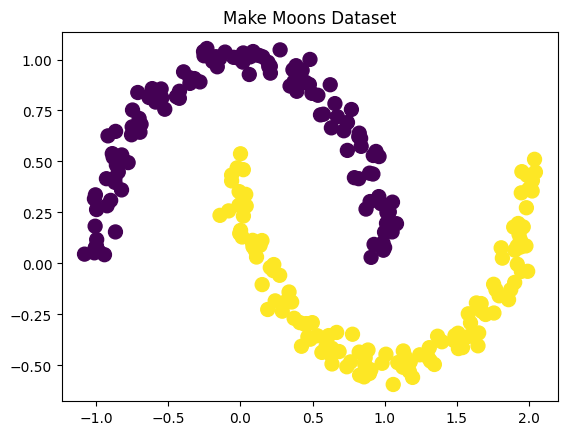

In [4]:
# =========================
# 1. Dataset
# =========================

X, y = make_moons(n_samples=250, noise=0.05, random_state=42)

plt.scatter(X[:,0], X[:,1], c=y, s=100)
plt.title("Make Moons Dataset")
plt.show()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [10]:
# convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train.reshape(-1,1), dtype=torch.float32)
y_test = torch.tensor(y_test.reshape(-1,1), dtype=torch.float32)


In [5]:
# =========================
# 2. Model
# =========================

class SigmoidNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,1), nn.Sigmoid(),
        )

    def forward(self,x):
        return self.net(x)


model = SigmoidNet()

# Deep Neural Network with Sigmoid

এই model এ আমরা:

• অনেক hidden layer ব্যবহার করেছি
• activation function হিসেবে Sigmoid ব্যবহার করেছি

Sigmoid activation এর derivative খুব ছোট হয়ে যায়
যখন input বড় বা ছোট হয়।

Backpropagation এ gradient layer থেকে layer এ propagate হওয়ার সময়
বারবার ছোট হতে থাকে।

Result:

Early layers এ gradient প্রায় 0 হয়ে যায়।

In [6]:
# =========================
# 3. Loss + Optimizer
# =========================

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)




In [7]:


# =========================
# 4. Save Initial Weights
# =========================

old_weights = model.net[0].weight.data.clone().numpy()

In [8]:
# for plotting weight movement
initial_weights = model.net[0].weight.data.clone()
weight_changes = []

In [11]:
# =========================
# 5. Training
# =========================

epochs = 100

for epoch in range(epochs):

    optimizer.zero_grad()

    y_pred = model(X_train)

    loss = criterion(y_pred, y_train)

    loss.backward()

    optimizer.step()

    # track weight movement
    current_weights = model.net[0].weight.data.clone()

    change = torch.mean(torch.abs(current_weights - initial_weights)).item()

    weight_changes.append(change)

    if epoch % 10 == 0:
        print(f"Epoch {epoch} Loss: {loss.item():.4f}")

Epoch 0 Loss: 0.6968
Epoch 10 Loss: 0.6942
Epoch 20 Loss: 0.6931
Epoch 30 Loss: 0.6930
Epoch 40 Loss: 0.6930
Epoch 50 Loss: 0.6930
Epoch 60 Loss: 0.6929
Epoch 70 Loss: 0.6929
Epoch 80 Loss: 0.6929
Epoch 90 Loss: 0.6929


# Training Process

Training loop এ আমরা নিচের step follow করি:

1. forward pass
2. loss calculation
3. backward pass
4. weight update

এখানে আমরা weight change track করছি
যাতে বুঝতে পারি training এর সময় weight কতটা update হচ্ছে।

In [12]:
# =========================
# 6. Save New Weights
# =========================

new_weights = model.net[0].weight.data.clone().numpy()


In [13]:

# =========================
# 7. Compute Gradient
# =========================

learning_rate = 0.001

gradient = (old_weights - new_weights) / learning_rate

percent_change = np.abs(100 * (old_weights - new_weights) / old_weights)

print("\nGradient:\n", gradient)

print("\nPercent Change:\n", percent_change)



Gradient:
 [[0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]]

Percent Change:
 [[0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]]


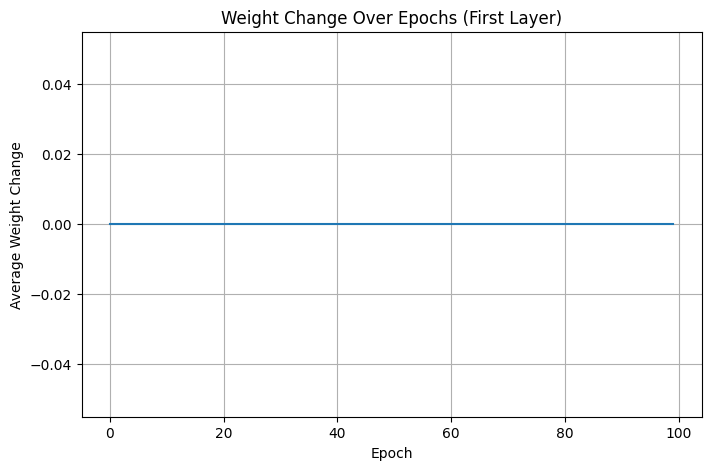

In [14]:
# =========================
# 8. Plot Weight Change
# =========================

plt.figure(figsize=(8,5))
plt.plot(weight_changes)

plt.xlabel("Epoch")
plt.ylabel("Average Weight Change")
plt.title("Weight Change Over Epochs (First Layer)")
plt.grid(True)

plt.show()

# Detecting Vanishing Gradient

Vanishing Gradient problem বোঝার একটি practical উপায় হলো **training এর সময় weight update পর্যবেক্ষণ করা**।

Backpropagation এর সময় gradient ব্যবহার করে weight update করা হয়:

---

## Weight Update Rule

W_new = W_old − η × gradient

**যেখানে:**

- **η (eta)** = Learning rate  
- **gradient** = loss এর প্রতি weight এর derivative  

---

## Vanishing Gradient হলে কি হয়?

যদি **gradient খুব ছোট হয়ে যায় (≈ 0)**, তাহলে:

- Weight update প্রায় বন্ধ হয়ে যায়  
- Network শেখা খুব ধীর হয়ে যায়  
- **Early layers effectively train হতে পারে না**

---

## Notebook এ আমরা কি করেছি?

এই notebook এ আমরা **vanishing gradient detect করার জন্য** নিচের কাজগুলো করেছি:

1️⃣ Training শুরু হওয়ার আগে **initial weights save** করেছি  

2️⃣ Training শেষে **updated weights collect** করেছি  

3️⃣ দুইটার difference ব্যবহার করে **average weight change** হিসাব করেছি

---

## Weight Change Calculation

weight_change = |W_new − W_old|

---

## Visualization

এই **weight change epoch অনুযায়ী plot** করলে আমরা gradient behaviour বুঝতে পারি।

---

# Observation

উপরের graph এ দেখা যাচ্ছে:

- **First layer এর weight change প্রায় 0 এর কাছাকাছি**
- **Epoch বাড়লেও weight update খুব কম হচ্ছে**

➡️ এটা নির্দেশ করে যে **early layer এ gradient খুব ছোট হয়ে গেছে**, অর্থাৎ  
**Vanishing Gradient problem ঘটছে।**

# Techniques to Prevent Vanishing Gradient

1️⃣ Reduce Complexity (Layer কমানো)

In [16]:
# =========================
# 2. Model
# =========================

class SigmoidNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 32),
            nn.Sigmoid(),
            nn.Linear(32, 16),
            nn.Sigmoid(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.net(x)


model = SigmoidNet()

Epoch 0 Loss: 0.6998
Epoch 10 Loss: 0.6928
Epoch 20 Loss: 0.6884
Epoch 30 Loss: 0.6845
Epoch 40 Loss: 0.6802
Epoch 50 Loss: 0.6754
Epoch 60 Loss: 0.6695
Epoch 70 Loss: 0.6624
Epoch 80 Loss: 0.6536
Epoch 90 Loss: 0.6430

Gradient:
 [[ 126.889206 -127.29383 ]
 [ 116.54782  -117.55313 ]
 [ 138.17767  -139.10936 ]
 [-118.18769   119.52191 ]
 [-132.02858   131.67053 ]
 [-126.157265  126.03604 ]
 [-132.94821   134.0828  ]
 [-134.69815   135.5623  ]
 [ 121.31485  -122.58857 ]
 [-116.06134   115.945946]
 [  32.91836   -30.545858]
 [ -90.06211    89.895004]
 [ 124.219444 -125.71963 ]
 [-127.653     127.7035  ]
 [ 126.66761  -128.93358 ]
 [  94.68964   -94.88916 ]
 [ 131.7087   -133.2167  ]
 [ 115.667145 -116.94052 ]
 [ -49.433712   49.977898]
 [ 101.14687  -102.42699 ]
 [ -15.864074   17.461   ]
 [-134.86775   136.0687  ]
 [-139.79953   140.2024  ]
 [ -95.17639    95.670876]
 [ 126.25342  -126.751564]
 [ -44.505474   45.91992 ]
 [-127.63139   128.9913  ]
 [ 105.54331  -106.0014  ]
 [-124.83435 

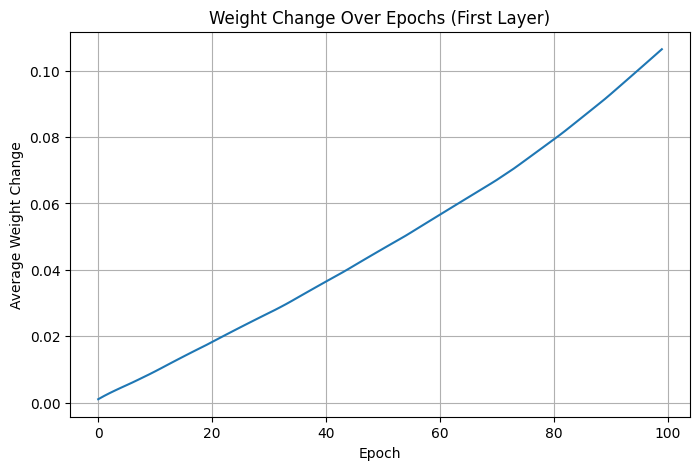

In [17]:
# =========================
# 3. Loss + Optimizer
# =========================

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)



# =========================
# 4. Save Initial Weights
# =========================

old_weights = model.net[0].weight.data.clone().numpy()


# for plotting weight movement
initial_weights = model.net[0].weight.data.clone()
weight_changes = []


# =========================
# 5. Training
# =========================

epochs = 100

for epoch in range(epochs):

    optimizer.zero_grad()

    y_pred = model(X_train)

    loss = criterion(y_pred, y_train)

    loss.backward()

    optimizer.step()

    # track weight movement
    current_weights = model.net[0].weight.data.clone()

    change = torch.mean(torch.abs(current_weights - initial_weights)).item()

    weight_changes.append(change)

    if epoch % 10 == 0:
        print(f"Epoch {epoch} Loss: {loss.item():.4f}")



# =========================
# 6. Save New Weights
# =========================

new_weights = model.net[0].weight.data.clone().numpy()



# =========================
# 7. Compute Gradient
# =========================

learning_rate = 0.001

gradient = (old_weights - new_weights) / learning_rate

percent_change = np.abs(100 * (old_weights - new_weights) / old_weights)

print("\nGradient:\n", gradient)

print("\nPercent Change:\n", percent_change)


# =========================
# 8. Plot Weight Change
# =========================

plt.figure(figsize=(8,5))
plt.plot(weight_changes)

plt.xlabel("Epoch")
plt.ylabel("Average Weight Change")
plt.title("Weight Change Over Epochs (First Layer)")
plt.grid(True)

plt.show()

2️⃣ Replace Sigmoid with ReLU

In [18]:
# =========================
# 2. Model
# =========================

class SigmoidNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.net(x)


model = SigmoidNet()

Epoch 0 Loss: 0.6963
Epoch 10 Loss: 0.6368
Epoch 20 Loss: 0.5539
Epoch 30 Loss: 0.4406
Epoch 40 Loss: 0.3327
Epoch 50 Loss: 0.2612
Epoch 60 Loss: 0.2127
Epoch 70 Loss: 0.1734
Epoch 80 Loss: 0.1350
Epoch 90 Loss: 0.0984

Gradient:
 [[ -68.139755    90.00557  ]
 [ -44.541985   -58.100906 ]
 [ 125.596725    -9.704679 ]
 [  90.91085    -56.911137 ]
 [ -49.0005     -90.64236  ]
 [-114.5766      29.809786 ]
 [ -56.57269     -8.70341  ]
 [   0.           0.       ]
 [  -2.781078    44.249054 ]
 [  68.53404    -72.30156  ]
 [   8.740187   -65.0165   ]
 [ -57.21086     52.483578 ]
 [   0.           0.       ]
 [  46.188404    49.4346   ]
 [   0.           0.       ]
 [ 128.23283    -94.30305  ]
 [ -79.53595    -52.821335 ]
 [-110.57263    -34.95878  ]
 [   0.           0.       ]
 [   0.           0.       ]
 [ -32.57951     37.72032  ]
 [ -97.41246     78.33677  ]
 [ -75.24269    -42.39848  ]
 [  14.953196    55.646416 ]
 [   0.           0.       ]
 [  75.40193    -44.868706 ]
 [ -16.314983  

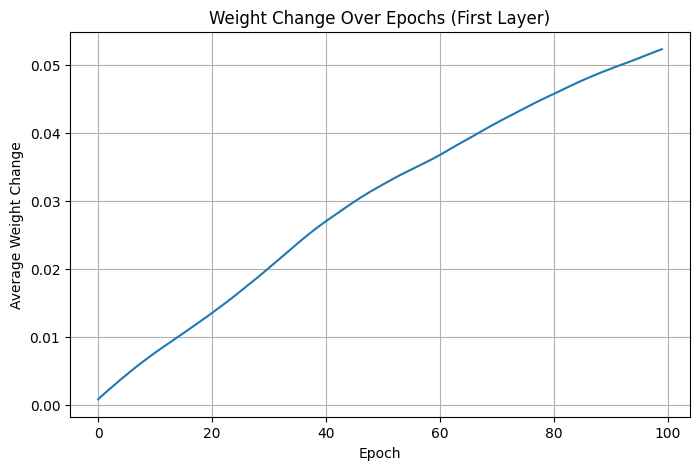

In [19]:
# =========================
# 3. Loss + Optimizer
# =========================

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)



# =========================
# 4. Save Initial Weights
# =========================

old_weights = model.net[0].weight.data.clone().numpy()


# for plotting weight movement
initial_weights = model.net[0].weight.data.clone()
weight_changes = []


# =========================
# 5. Training
# =========================

epochs = 100

for epoch in range(epochs):

    optimizer.zero_grad()

    y_pred = model(X_train)

    loss = criterion(y_pred, y_train)

    loss.backward()

    optimizer.step()

    # track weight movement
    current_weights = model.net[0].weight.data.clone()

    change = torch.mean(torch.abs(current_weights - initial_weights)).item()

    weight_changes.append(change)

    if epoch % 10 == 0:
        print(f"Epoch {epoch} Loss: {loss.item():.4f}")



# =========================
# 6. Save New Weights
# =========================

new_weights = model.net[0].weight.data.clone().numpy()



# =========================
# 7. Compute Gradient
# =========================

learning_rate = 0.001

gradient = (old_weights - new_weights) / learning_rate

percent_change = np.abs(100 * (old_weights - new_weights) / old_weights)

print("\nGradient:\n", gradient)

print("\nPercent Change:\n", percent_change)


# =========================
# 8. Plot Weight Change
# =========================

plt.figure(figsize=(8,5))
plt.plot(weight_changes)

plt.xlabel("Epoch")
plt.ylabel("Average Weight Change")
plt.title("Weight Change Over Epochs (First Layer)")
plt.grid(True)

plt.show()